Bentuk Dataset: 25000 baris, 15 kolom
--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 

/tmp/ipykernel_1657/3966512007.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='delivery_status', palette='Set2')


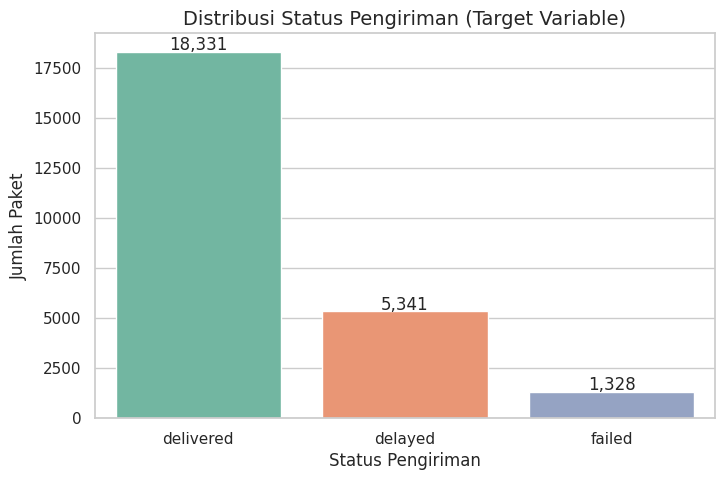

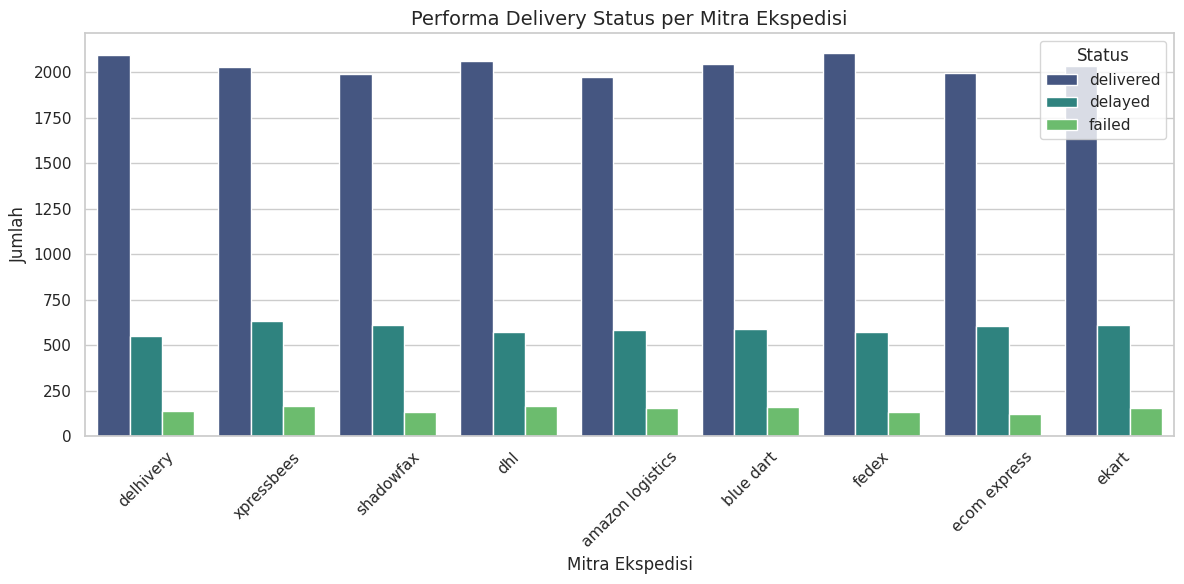

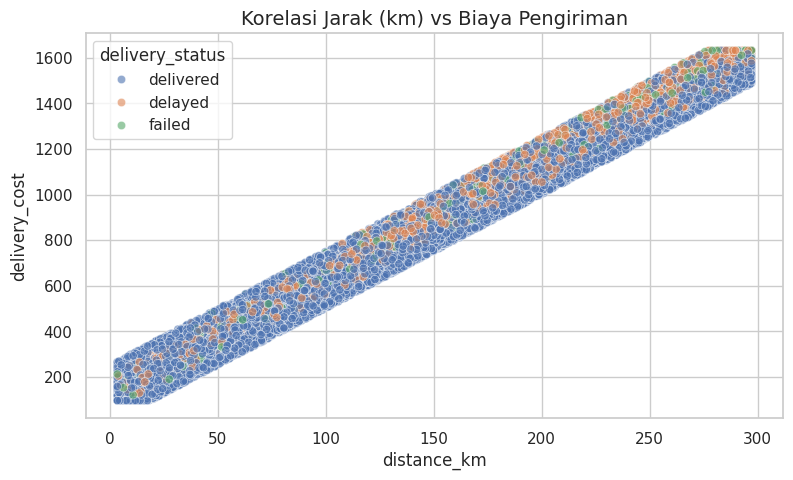

In [ ]:
# [Cell 1] - Import Library & Setup Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
%matplotlib inline

# Memuat Dataset
df = pd.read_csv('Delivery_Logistics.csv')
print(f"Bentuk Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

# [Cell 2] - Inspeksi Ringkasan Data & Missing Values
print("--- INFO DATASET ---")
print(df.info())

print("\n--- PEMERIKSAAN MISSING VALUES ---")
print(df.isnull().sum())

# [Cell 3] - Distribusi Target Variable (delivery_status)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='delivery_status', palette='Set2')
plt.title('Distribusi Status Pengiriman (Target Variable)', fontsize=14)
plt.xlabel('Status Pengiriman')
plt.ylabel('Jumlah Paket')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# [Cell 4] - Analisis Performa Mitra Ekspedisi
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='delivery_partner', hue='delivery_status', palette='viridis')
plt.title('Performa Delivery Status per Mitra Ekspedisi', fontsize=14)
plt.xlabel('Mitra Ekspedisi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# [Cell 5] - Hubungan Jarak & Biaya Pengiriman
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='distance_km', y='delivery_cost', hue='delivery_status', alpha=0.6)
plt.title('Korelasi Jarak (km) vs Biaya Pengiriman', fontsize=14)
plt.show()